# Predicting Diabetes Risk with Logistic Regression

> A hands-on logistic regression on the Pima Indians Diabetes dataset: 768 women aged 21+ of Pima Indian heritage. I clean impossible zero readings, fit a logistic regression with statsmodels, drop non-significant predictors one at a time, interpret the remaining coefficients as odds ratios, and then tune the decision threshold so the model catches more patients who actually have diabetes.

## Executive Summary

| # | Finding | Evidence | So what |
|---|---|---|---|
| 1 | **Many "measurements" are really missing values** | **49%** of Insulin and **30%** of SkinThickness readings are recorded as 0, which is physically impossible | They're treated as missing and filled with training-set medians, so the test set never leaks into training |
| 2 | **Four predictors carry the model** | Glucose, BMI, number of pregnancies and family history (Pedigree) stay significant. Blood pressure, skin thickness, insulin and age drop out | A simpler 4-variable model is as accurate as the full 8-variable one |
| 3 | **Glucose and BMI are the practical levers** | Every **+10 mg/dL** of glucose raises the odds of diabetes by about **46%**; every **+5 BMI points** by about **59%** | These are measurable, modifiable risk factors to flag in screening |
| 4 | **At the default 0.5 cutoff the model misses half the diabetics** | Test accuracy **75%**, but recall only **52%** (42 of 81 diabetic patients caught) | Accuracy alone hides the cost that matters most in screening |
| 5 | **A lower cutoff fixes that** | At a cutoff of **0.30**, test recall rises to **75%** (61 of 81) with the same accuracy | For screening, use the lower threshold and confirm positives with a follow-up test |

Details, charts and interpretation follow below.

## Business Context

Diabetes is one of the most common chronic diseases worldwide, and the number of patients keeps growing. Its exact cause is still unknown, but both genetics and lifestyle play a major role. It raises the risk of heart disease, nerve damage and other complications. It can't be cured, but early detection and treatment make it much easier to manage.

Researchers at the Bio-Solutions lab want to understand the disease better among women and to **identify patients at risk** of diabetes. Every patient in this dataset is a woman at least 21 years old of Pima Indian heritage.

### Data Dictionary

| Column | Description |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration 2 hours into an oral glucose tolerance test (mg/dL) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skinfold thickness (mm) |
| `Insulin` | 2-hour serum insulin (μU/mL) |
| `BMI` | Body mass index (kg/m²) |
| `Pedigree` | Diabetes pedigree function: a score for likelihood of diabetes based on family history |
| `Age` | Age in years |
| `Class` | **Target:** 1 = diabetic, 0 = not diabetic |

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# Consistent styling for every chart in the report
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
BASE = "#9BB0C8"      # neutral / non-diabetic
ACCENT = "#1F4E79"    # highlighted / diabetic
pd.set_option("display.max_columns", None)

In [2]:
# Load the data ONCE; every later cell works from this dataframe
data = pd.read_csv("pima-indians-diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Overview and Cleaning

In [3]:
print(f"Rows: {data.shape[0]}   Columns: {data.shape[1]}")
print(f"Missing values: {data.isnull().sum().sum()}   Duplicate rows: {data.duplicated().sum()}")
data.describe().round(2)

Rows: 768   Columns: 9
Missing values: 0   Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


There are no missing values on paper, but the summary shows minimums of **0** for Glucose, BloodPressure, SkinThickness, Insulin and BMI. None of these can be 0 in a living person, so the zeros are really **missing measurements**. (Zero is valid for Pregnancies.)

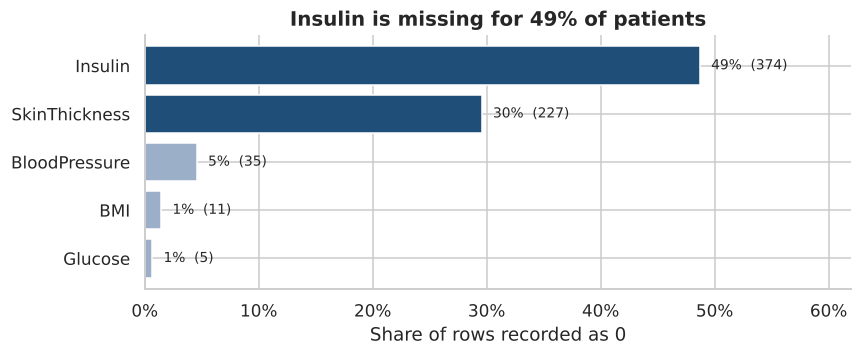

In [4]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zeros = (data[zero_cols] == 0).sum()

fig, ax = plt.subplots(figsize=(8, 3.4))
order = zeros.sort_values().index
ax.barh(order, zeros[order] / len(data), color=[ACCENT if v / len(data) > 0.2 else BASE for v in zeros[order]])
for y, c in enumerate(order):
    ax.text(zeros[c] / len(data) + 0.01, y, f"{zeros[c] / len(data):.0%}  ({zeros[c]})", va="center", fontsize=9)
ax.set_xlim(0, 0.62); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title(f"Insulin is missing for {zeros['Insulin'] / len(data):.0%} of patients")
ax.set_xlabel("Share of rows recorded as 0"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Cleaning plan.**

* Replace these zeros with `NaN` now.
* **Fill them only after the train/test split**, using the **training-set median** of each column.
  * The median is used because Insulin and SkinThickness are right-skewed.
  * Using training-set values keeps any information from the test set out of the model.

Insulin and SkinThickness are missing for so many patients that their filled-in values are rough. That's worth remembering when we see whether they matter.

In [5]:
data[zero_cols] = data[zero_cols].replace(0, np.nan)
data.isna().sum()

Pregnancies        0
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Pedigree           0
Age                0
Class              0
dtype: int64

## 3. Exploring the Data

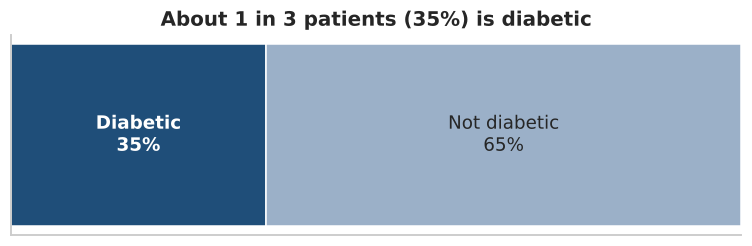

,patients
Class,
Not diabetic,500
Diabetic,268


In [6]:
class_share = data["Class"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 2.4))
ax.barh(["Patients"], [class_share[1]], color=ACCENT)
ax.barh(["Patients"], [class_share[0]], left=[class_share[1]], color=BASE)
ax.text(class_share[1] / 2, 0, f"Diabetic\n{class_share[1]:.0%}", ha="center", va="center", color="white", fontweight="bold")
ax.text(class_share[1] + class_share[0] / 2, 0, f"Not diabetic\n{class_share[0]:.0%}", ha="center", va="center")
ax.set_xlim(0, 1); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"About 1 in 3 patients ({class_share[1]:.0%}) is diabetic")
plt.tight_layout(); plt.show()

data["Class"].value_counts().rename(index={0: "Not diabetic", 1: "Diabetic"}).to_frame("patients")

The classes are moderately imbalanced. A model that always predicted "not diabetic" would be 65% accurate while catching no one, so **recall** (the share of diabetic patients the model catches) is the number to watch, not just accuracy.

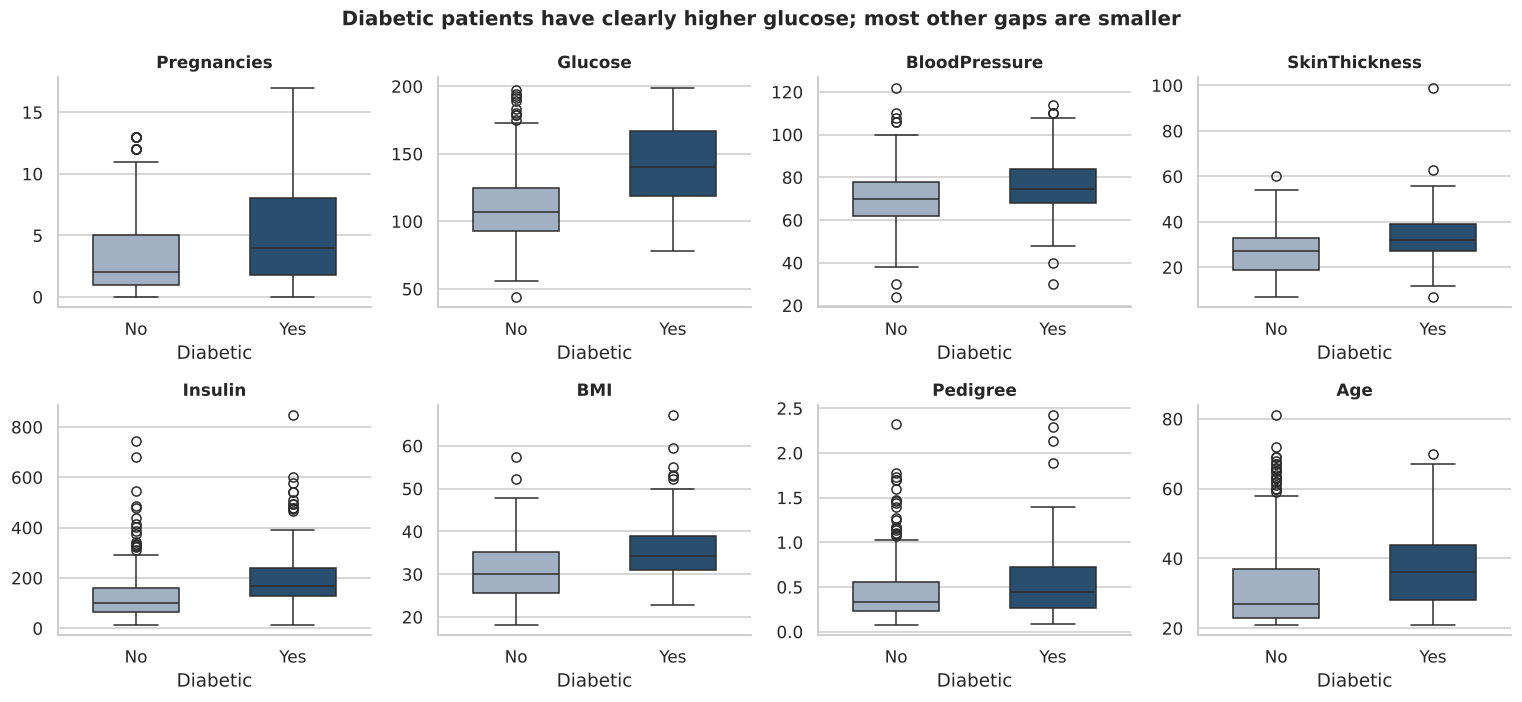

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
Class,,,,,,,,
Not diabetic,2.0,107.0,70.0,27.0,102.5,30.1,0.3,27.0
Diabetic,4.0,140.0,74.5,32.0,169.5,34.3,0.4,36.0


In [7]:
features = [c for c in data.columns if c != "Class"]

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=data, x="Class", y=col, hue="Class", palette={0: BASE, 1: ACCENT},
                legend=False, width=0.55, ax=ax)
    ax.set_xticks([0, 1], ["No", "Yes"]); ax.set_xlabel("Diabetic"); ax.set_ylabel("")
    ax.set_title(col, fontsize=11)
fig.suptitle("Diabetic patients have clearly higher glucose; most other gaps are smaller",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

data.groupby("Class")[features].median().rename(index={0: "Not diabetic", 1: "Diabetic"}).round(1)

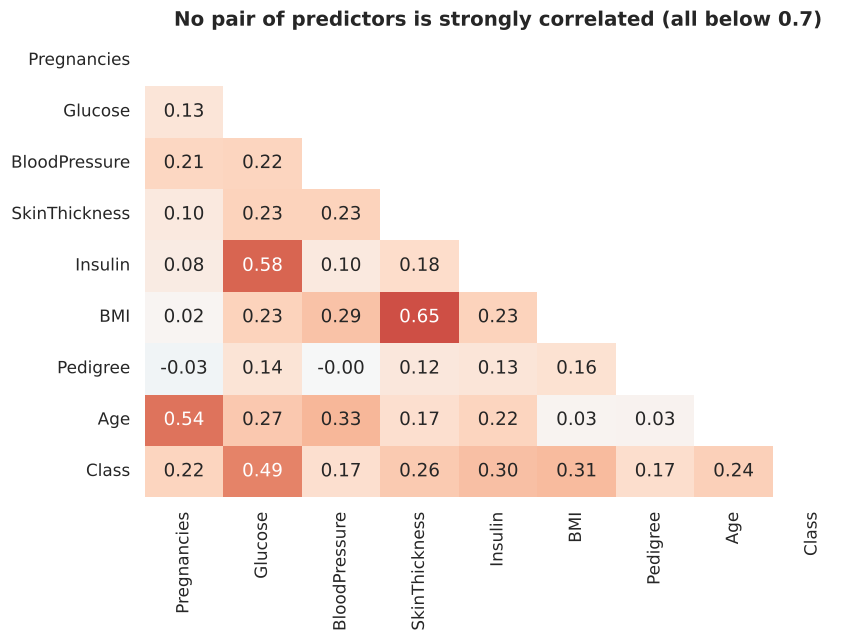

In [8]:
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, cbar=False, ax=ax)
ax.grid(False)
ax.set_title("No pair of predictors is strongly correlated (all below 0.7)")
plt.tight_layout(); plt.show()

**Takeaway.** Glucose is the clearest single difference between the two groups: a median of 140 mg/dL for diabetic patients vs 107 for the rest. Age, BMI, pregnancies and insulin also run higher in diabetic patients. The strongest correlations between predictors are expected pairs (age with pregnancies, BMI with skin thickness, glucose with insulin), and none is high enough to cause problems for the model.

## 4. Splitting and Preparing the Data

70% of patients go into training and 30% into the test set, **stratified** so both keep the same diabetic/non-diabetic mix. Missing values are then filled with training-set medians, and a constant (intercept) column is added, which statsmodels needs.

In [9]:
X = data.drop(columns="Class")
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)

train_medians = X_train.median()
X_train = sm.add_constant(X_train.fillna(train_medians))
X_test = sm.add_constant(X_test.fillna(train_medians))

print(f"Train: {len(X_train)} patients ({y_train.mean():.1%} diabetic)")
print(f"Test:  {len(X_test)} patients ({y_test.mean():.1%} diabetic)")
print(f"Missing values left: {X_train.isna().sum().sum() + X_test.isna().sum().sum()}")

Train: 537 patients (34.8% diabetic)
Test:  231 patients (35.1% diabetic)
Missing values left: 0


## 5. Fitting the Full Model

In [10]:
full_model = sm.Logit(y_train, X_train).fit(disp=False)
print(full_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Fri, 09 Oct 2026   Pseudo R-squ.:                  0.3039
Time:                        18:29:09   Log-Likelihood:                -241.62
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 3.171e-41
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.6995      1.020     -9.508      0.000     -11.699      -7.700
Pregnancies       0.1446      0.039      3.703      0.000       0.068       0.221
Glucose           0.0366      0.005     

Coefficients are on the **log-odds** scale, and `P>|z|` is each predictor's p-value. Before reading p-values, I check for **multicollinearity**: highly correlated predictors make coefficients and p-values unreliable. The variance inflation factor (VIF) measures it, and values above 5 are a concern. (The constant's VIF can be ignored.)

In [11]:
vif = pd.Series([variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
                index=X_train.columns, name="VIF").drop("const").round(2)
vif.sort_values(ascending=False).to_frame()

,VIF
Age,1.63
BMI,1.55
SkinThickness,1.45
Pregnancies,1.42
Glucose,1.37
BloodPressure,1.23
Insulin,1.23
Pedigree,1.05


Every VIF is below 2, so multicollinearity isn't a problem and the p-values can be trusted.

## 6. Dropping Non-Significant Predictors

I use **backward elimination**: refit the model, drop the predictor with the highest p-value if it's above 0.05, and repeat until every remaining predictor is significant. The table logs each step, so you can see that dropping these predictors costs almost no accuracy.

In [12]:
def train_accuracy(model, cols):
    return accuracy_score(y_train, model.predict(X_train[cols]) > 0.5)

cols = list(X_train.columns)
steps = []
while True:
    model = sm.Logit(y_train, X_train[cols]).fit(disp=False)
    pvals = model.pvalues.drop("const")
    worst = pvals.idxmax()
    steps.append({"predictors": len(cols) - 1, "train accuracy": round(train_accuracy(model, cols), 3),
                  "highest p-value": f"{worst} ({pvals.max():.3f})",
                  "action": f"drop {worst}" if pvals.max() > 0.05 else "stop: all significant"})
    if pvals.max() <= 0.05:
        break
    cols.remove(worst)

final_model = model
final_cols = cols
pd.DataFrame(steps)

,predictors,train accuracy,highest p-value,action
0,8,0.784,SkinThickness (0.965),drop SkinThickness
1,7,0.784,BloodPressure (0.698),drop BloodPressure
2,6,0.784,Insulin (0.668),drop Insulin
3,5,0.786,Age (0.309),drop Age
4,4,0.782,Pedigree (0.003),stop: all significant


In [13]:
print(final_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            4
Date:                Fri, 09 Oct 2026   Pseudo R-squ.:                  0.3019
Time:                        18:29:09   Log-Likelihood:                -242.31
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 3.304e-44
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -9.6704      0.890    -10.869      0.000     -11.414      -7.927
Pregnancies     0.1646      0.034      4.884      0.000       0.099       0.231
Glucose         0.0380      0.004      8.936    

**Takeaway.** Skin thickness, blood pressure, insulin and age drop out, and training accuracy barely moves (0.784 → 0.782). Insulin and skin thickness were the two columns with the most filled-in values, so it isn't surprising they add little. Age drops out because pregnancies, which rise with age, already carry most of that information. The final model uses **Pregnancies, Glucose, BMI and Pedigree**.

## 7. Interpreting the Coefficients

Logistic regression coefficients are changes in log-odds, so I convert them to **odds ratios** with `exp(coef)`. An odds ratio of 1.20 means a 20% increase in the odds of diabetes for a one-unit increase in that predictor, holding the others constant.

A one-unit change isn't always meaningful. One mg/dL of glucose is tiny, and one point of Pedigree is most of its range. So the table also shows the effect for a **practical step** in each predictor.

In [14]:
steps_ = {"Pregnancies": (1, "1 more pregnancy"), "Glucose": (10, "+10 mg/dL"),
          "BMI": (5, "+5 BMI points"), "Pedigree": (0.1, "+0.1 pedigree score")}

coefs = final_model.params.drop("const")
ci = final_model.conf_int().drop("const")
odds = pd.DataFrame({
    "odds ratio (per unit)": np.exp(coefs),
    "practical step": [steps_[c][1] for c in coefs.index],
    "odds ratio (per step)": [np.exp(coefs[c] * steps_[c][0]) for c in coefs.index],
    "95% CI (per step)": [f"{np.exp(ci.loc[c, 0] * steps_[c][0]):.2f} – {np.exp(ci.loc[c, 1] * steps_[c][0]):.2f}"
                          for c in coefs.index],
})
odds["change in odds (per step)"] = (odds["odds ratio (per step)"] - 1).map("{:+.0%}".format)
odds.round(3)

,odds ratio (per unit),practical step,odds ratio (per step),95% CI (per step),change in odds (per step)
Pregnancies,1.179,1 more pregnancy,1.179,1.10 – 1.26,+18%
Glucose,1.039,+10 mg/dL,1.463,1.35 – 1.59,+46%
BMI,1.097,+5 BMI points,1.591,1.32 – 1.91,+59%
Pedigree,2.842,+0.1 pedigree score,1.110,1.04 – 1.19,+11%


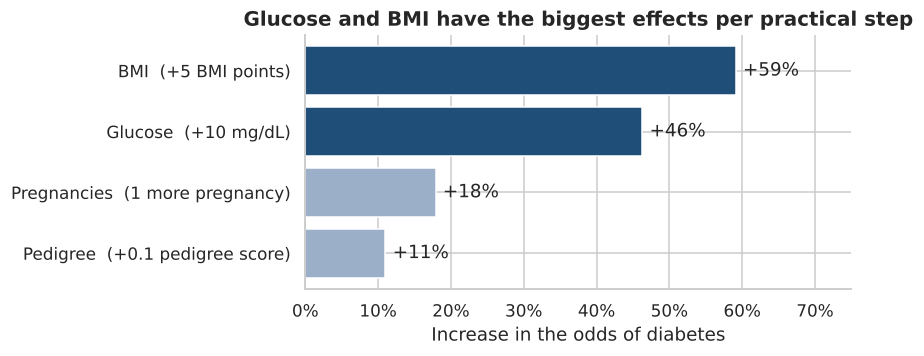

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.4))
order = odds["odds ratio (per step)"].sort_values().index
ax.barh([f"{c}  ({steps_[c][1]})" for c in order], odds.loc[order, "odds ratio (per step)"] - 1,
        color=[ACCENT if c in ("Glucose", "BMI") else BASE for c in order])
for y_pos, c in enumerate(order):
    v = odds.loc[c, "odds ratio (per step)"] - 1
    ax.text(v + 0.01, y_pos, f"+{v:.0%}", va="center")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_xlim(0, 0.75)
ax.set_title("Glucose and BMI have the biggest effects per practical step")
ax.set_xlabel("Increase in the odds of diabetes"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Reading the odds ratios** (each one holds the other predictors constant):

* **Glucose:** each extra **10 mg/dL** raises the odds of diabetes by about **46%** (1.04× per single mg/dL).
* **BMI:** each extra **5 points** raises the odds by about **59%** (1.10× per point).
* **Pregnancies:** each additional pregnancy raises the odds by about **18%** (1.18×).
* **Pedigree:** each **+0.1** in the family-history score raises the odds by about **11%**. Per full point it's 2.84×, but that's an unrealistically large step on this scale, and its confidence interval is wide.

All four effects are positive: higher values mean higher risk.

## 8. How Well Does the Model Perform?

In [16]:
def evaluate(X, y, threshold=0.5):
    """Classification metrics for the final model at a given probability cutoff."""
    proba = final_model.predict(X[final_cols])
    pred = (proba > threshold).astype(int)
    return {"Accuracy": accuracy_score(y, pred), "Recall": recall_score(y, pred),
            "Precision": precision_score(y, pred), "F1": f1_score(y, pred),
            "ROC-AUC": roc_auc_score(y, proba)}

def plot_confusion(ax, X, y, threshold, title):
    pred = (final_model.predict(X[final_cols]) > threshold).astype(int)
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Not diabetic", "Diabetic"], yticklabels=["Not diabetic", "Diabetic"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title, fontsize=11); ax.grid(False)

pd.DataFrame({"Train": evaluate(X_train, y_train), "Test": evaluate(X_test, y_test)}).round(3)

,Train,Test
Accuracy,0.782,0.749
Recall,0.588,0.519
Precision,0.733,0.689
F1,0.653,0.592
ROC-AUC,0.853,0.821


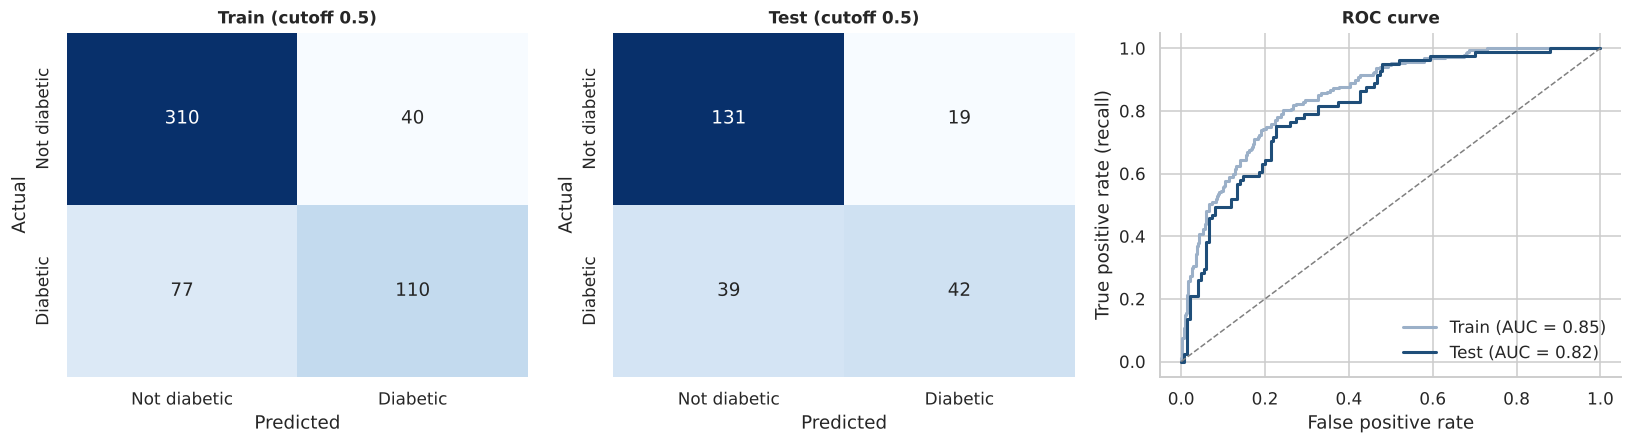

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_confusion(axes[0], X_train, y_train, 0.5, "Train (cutoff 0.5)")
plot_confusion(axes[1], X_test, y_test, 0.5, "Test (cutoff 0.5)")

for X_, y_, name, color in [(X_train, y_train, "Train", BASE), (X_test, y_test, "Test", ACCENT)]:
    proba = final_model.predict(X_[final_cols])
    fpr, tpr, _ = roc_curve(y_, proba)
    axes[2].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc_score(y_, proba):.2f})")
axes[2].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate (recall)")
axes[2].set_title("ROC curve", fontsize=11); axes[2].legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

**Takeaway.** The model generalizes reasonably: test accuracy is 75% vs 78% on training, and ROC-AUC is 0.82 vs 0.85. But at the default cutoff of 0.5 it catches only **52%** of diabetic patients in the test set (42 of 81). For a screening tool, missing half the people who have the disease is the most serious kind of error.

## 9. Choosing a Better Cutoff

The model outputs a probability, and 0.5 is just the default cutoff for calling someone "diabetic". Lowering it catches more diabetic patients at the cost of more false alarms. A common choice is the cutoff that maximizes **recall minus false positive rate** on the ROC curve (Youden's J). I pick it on the **training set** and then check it on the test set.

Chosen cutoff: 0.30


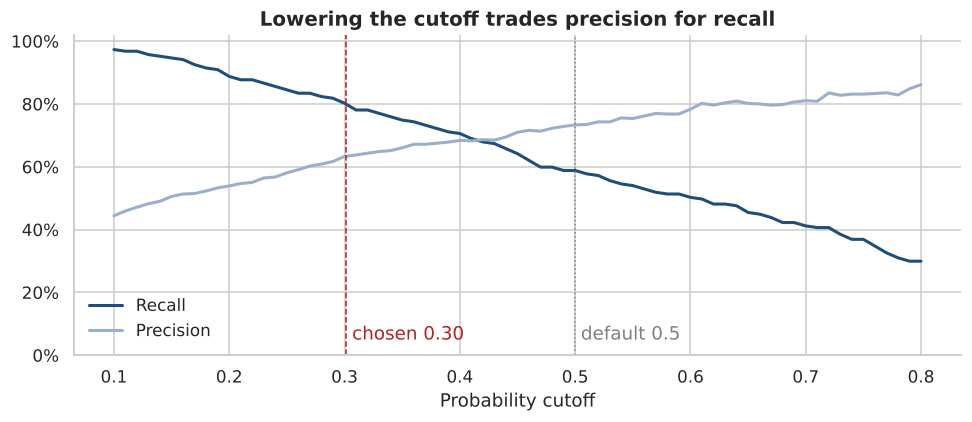

In [18]:
fpr, tpr, thresholds = roc_curve(y_train, final_model.predict(X_train[final_cols]))
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Chosen cutoff: {best_threshold:.2f}")

# How recall and precision trade off as the cutoff moves (training set)
grid = np.arange(0.1, 0.81, 0.01)
proba_train = final_model.predict(X_train[final_cols])
curve = pd.DataFrame({"Recall": [recall_score(y_train, proba_train > t) for t in grid],
                      "Precision": [precision_score(y_train, proba_train > t) for t in grid]}, index=grid)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curve.index, curve["Recall"], color=ACCENT, lw=2, label="Recall")
ax.plot(curve.index, curve["Precision"], color=BASE, lw=2, label="Precision")
ax.axvline(0.5, color="grey", linestyle=":", lw=1); ax.text(0.505, 0.05, "default 0.5", color="grey")
ax.axvline(best_threshold, color="firebrick", linestyle="--", lw=1)
ax.text(best_threshold + 0.005, 0.05, f"chosen {best_threshold:.2f}", color="firebrick")
ax.set_ylim(0, 1.02); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Lowering the cutoff trades precision for recall")
ax.set_xlabel("Probability cutoff"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

,"Test, cutoff 0.5","Test, cutoff 0.30"
Accuracy,0.749,0.753
Recall,0.519,0.753
Precision,0.689,0.622
F1,0.592,0.682


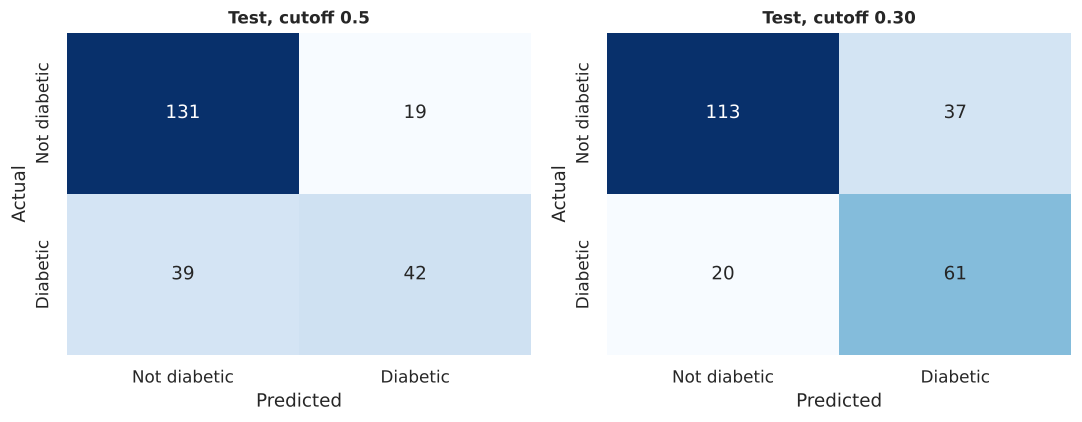

In [19]:
comparison = pd.DataFrame({"Test, cutoff 0.5": evaluate(X_test, y_test, 0.5),
                           f"Test, cutoff {best_threshold:.2f}": evaluate(X_test, y_test, best_threshold)}).round(3)
display(comparison.drop("ROC-AUC"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(axes[0], X_test, y_test, 0.5, "Test, cutoff 0.5")
plot_confusion(axes[1], X_test, y_test, best_threshold, f"Test, cutoff {best_threshold:.2f}")
plt.tight_layout(); plt.show()

**Takeaway.** Moving the cutoff from 0.5 to 0.30 raises test recall from **52% to 75%**, so the model catches 61 of 81 diabetic patients instead of 42. Accuracy stays about the same (75%). The cost is more false alarms (37 instead of 19), so precision drops from 69% to 62%. For a first-pass screen, followed by a proper diagnostic test, that's the right trade.

## 10. Conclusions and Recommendations

**1. Screen on glucose and BMI first.** They have the largest practical effects (+46% odds per 10 mg/dL of glucose, +59% per 5 BMI points), and both are cheap to measure and can be changed through treatment and lifestyle.

**2. Treat family history and number of pregnancies as risk flags.** Both raise risk independently of glucose and BMI, so they help prioritize who gets screened more often.

**3. Use the lower cutoff (about 0.30) for screening.** At 0.5 the model misses half the diabetic patients. At 0.30 it catches three out of four with the same accuracy, and the extra false alarms are resolved by a follow-up test.

**4. Fix data collection before reading too much into insulin and skin thickness.** About half the insulin readings and a third of the skin-thickness readings are missing. Their weak results here may reflect the missing data rather than a weak link to diabetes.

### Limitations and Next Steps

* 768 patients from one specific population (Pima Indian women aged 21+). The results may not carry over to other groups.
* Filling missing values with the median shrinks real differences. Multiple imputation, or simply dropping Insulin and SkinThickness, would be worth comparing.
* The data is a single snapshot, so the model estimates **association**, not cause.
* **Natural extension:** compare against a regularized logistic regression and a tree-based model using cross-validation, and choose the cutoff from the real costs of a missed diagnosis versus a false alarm.